In [1]:
import pandas as pd
import numpy as np 
import hashlib


## Dados 


### `Analise das fontes de dados:`
_____________________________________
_____________________________________


### Scrape ufc stats

In [2]:
event_details = pd.read_csv(r'C:\Users\Desktop\OneDrive\Desktop\Proj_pythons\base_dados\event_details.csv')
fight_details = pd.read_csv(r'C:\Users\Desktop\OneDrive\Desktop\Proj_pythons\base_dados\fight_details.csv')
fight_results = pd.read_csv(r'C:\Users\Desktop\OneDrive\Desktop\Proj_pythons\base_dados\fight_results.csv')
fight_stats = pd.read_csv(r'C:\Users\Desktop\OneDrive\Desktop\Proj_pythons\base_dados\fight_stats.csv')
fighter_details = pd.read_csv(r'C:\Users\Desktop\OneDrive\Desktop\Proj_pythons\base_dados\fighter_details.csv')
fighter_tott = pd.read_csv(r'C:\Users\Desktop\OneDrive\Desktop\Proj_pythons\base_dados\fighter_tott.csv')


In [3]:
display(event_details)
display(fight_details[fight_details['event_name']=='UFC Fight Night: Allen vs. Costa'])
display(fight_results[fight_results['event_name']=='UFC Fight Night: Allen vs. Costa'])
display(fight_stats[fight_stats['event_name']=='UFC Fight Night: Allen vs. Costa'])
# display(fighter_details)
display(fighter_tott[fighter_tott['fighter_name'].isin(['Arnold Allen','Melquizael Costa'])])

,event_name,url,event_date,event_location
0,UFC Fight Night: Allen vs. Costa,http://ufcstats.com/event-details/73abb7a5c57f...,2026-05-16,"Las Vegas, Nevada, USA"
1,UFC 328: Chimaev vs. Strickland,http://ufcstats.com/event-details/9eedac48b497...,2026-05-09,"Newark, New Jersey, USA"
2,UFC Fight Night: Della Maddalena vs. Prates,http://ufcstats.com/event-details/872b018076f8...,2026-05-02,"Perth, Western Australia, Australia"
3,UFC Fight Night: Sterling vs. Zalal,http://ufcstats.com/event-details/e60d773a0a42...,2026-04-25,"Las Vegas, Nevada, USA"
4,UFC Fight Night: Burns vs. Malott,http://ufcstats.com/event-details/c3ac8d0da7b0...,2026-04-18,"Winnipeg, Manitoba, Canada"
...,...,...,...,...
769,UFC 6: Clash of the Titans,http://ufcstats.com/event-details/1c3f5e85b59e...,1995-07-14,"Casper, Wyoming, USA"
770,UFC 5: The Return of the Beast,http://ufcstats.com/event-details/dedc3bb440d0...,1995-04-07,"Charlotte, North Carolina, USA"
771,UFC 4: Revenge of the Warriors,http://ufcstats.com/event-details/b60391da771d...,1994-12-16,"Tulsa, Oklahoma, USA"
772,UFC 3: The American Dream,http://ufcstats.com/event-details/1a49e0670dfa...,1994-09-09,"Charlotte, North Carolina, USA"


,event_name,bout,url
0,UFC Fight Night: Allen vs. Costa,Arnold Allen vs. Melquizael Costa,http://ufcstats.com/fight-details/e4aa60812489...
1,UFC Fight Night: Allen vs. Costa,Dooho Choi vs. Daniel Santos,http://ufcstats.com/fight-details/fc1266e2892e...
2,UFC Fight Night: Allen vs. Costa,Malcolm Wellmaker vs. Juan Diaz,http://ufcstats.com/fight-details/ecb7ff543dd4...
3,UFC Fight Night: Allen vs. Costa,Modestas Bukauskas vs. Christian Edwards,http://ufcstats.com/fight-details/57bd683efc79...
4,UFC Fight Night: Allen vs. Costa,Timmy Cuamba vs. Benardo Sopaj,http://ufcstats.com/fight-details/a6ec8573a9d3...
5,UFC Fight Night: Allen vs. Costa,Nikolay Veretennikov vs. Khaos Williams,http://ufcstats.com/fight-details/ec32745308e2...
6,UFC Fight Night: Allen vs. Costa,Tuco Tokkos vs. Ivan Erslan,http://ufcstats.com/fight-details/6242cda790f2...
7,UFC Fight Night: Allen vs. Costa,Tommy Gantt vs. Artur Minev,http://ufcstats.com/fight-details/c9e0aa88afb8...
8,UFC Fight Night: Allen vs. Costa,Ketlen Vieira vs. Jacqueline Cavalcanti,http://ufcstats.com/fight-details/5f7111b982bc...
9,UFC Fight Night: Allen vs. Costa,Cody Brundage vs. Andre Petroski,http://ufcstats.com/fight-details/48cb604345f1...


,event_name,bout,outcome,weight_class,method,round,time,time_format,referee,details,url,round_number
0,UFC Fight Night: Allen vs. Costa,Arnold Allen vs. Melquizael Costa,W/L,Featherweight Bout,Decision - Unanimous,5,5:00,5 Rnd (5-5-5-5-5),Chris Tognoni,Eric Colon 45 - 50.David Lethaby 45 - 50.Sal D...,http://ufcstats.com/fight-details/e4aa60812489...,5
1,UFC Fight Night: Allen vs. Costa,Dooho Choi vs. Daniel Santos,W/L,Featherweight Bout,KO/TKO,2,4:29,3 Rnd (5-5-5),Kerry Hatley,Punch to Body At Distance,http://ufcstats.com/fight-details/fc1266e2892e...,2
2,UFC Fight Night: Allen vs. Costa,Malcolm Wellmaker vs. Juan Diaz,L/W,Bantamweight Bout,Submission,2,4:08,3 Rnd (5-5-5),Eric McMahon,Rear Naked Choke,http://ufcstats.com/fight-details/ecb7ff543dd4...,2
3,UFC Fight Night: Allen vs. Costa,Modestas Bukauskas vs. Christian Edwards,W/L,Catch Weight Bout,Decision - Split,3,5:00,3 Rnd (5-5-5),Kerry Hatley,David Sutherland 28 - 29.Junichiro Kamijo 29 -...,http://ufcstats.com/fight-details/57bd683efc79...,3
4,UFC Fight Night: Allen vs. Costa,Timmy Cuamba vs. Benardo Sopaj,L/W,Bantamweight Bout,Submission,2,2:25,3 Rnd (5-5-5),Jerin Valel,Rear Naked Choke,http://ufcstats.com/fight-details/a6ec8573a9d3...,2
5,UFC Fight Night: Allen vs. Costa,Nikolay Veretennikov vs. Khaos Williams,L/W,Welterweight Bout,KO/TKO,1,3:31,3 Rnd (5-5-5),Chris Tognoni,Punches to Head At Distance,http://ufcstats.com/fight-details/ec32745308e2...,1
6,UFC Fight Night: Allen vs. Costa,Tuco Tokkos vs. Ivan Erslan,L/W,Light Heavyweight Bout,Decision - Unanimous,3,5:00,3 Rnd (5-5-5),Eric McMahon,Adalaide Byrd 28 - 29.Junichiro Kamijo 28 - 29...,http://ufcstats.com/fight-details/6242cda790f2...,3
7,UFC Fight Night: Allen vs. Costa,Tommy Gantt vs. Artur Minev,W/L,Lightweight Bout,KO/TKO,2,2:51,3 Rnd (5-5-5),Kerry Hatley,Punches to Head From Back Control,http://ufcstats.com/fight-details/c9e0aa88afb8...,2
8,UFC Fight Night: Allen vs. Costa,Ketlen Vieira vs. Jacqueline Cavalcanti,W/L,Women's Bantamweight Bout,Decision - Unanimous,3,5:00,3 Rnd (5-5-5),Jerin Valel,Eric Colon 28 - 29.Sal D'amato 28 - 29.David L...,http://ufcstats.com/fight-details/5f7111b982bc...,3
9,UFC Fight Night: Allen vs. Costa,Cody Brundage vs. Andre Petroski,W/L,Middleweight Bout,KO/TKO,2,0:44,3 Rnd (5-5-5),Chris Tognoni,Punches to Head From Guard,http://ufcstats.com/fight-details/48cb604345f1...,2


,event_name,bout,round,fighter_name,knockdowns,sig_str,sig_str_pct,total_str,takedowns,takedown_pct,...,body_str_landed,body_str_attempted,leg_str_landed,leg_str_attempted,distance_str_landed,distance_str_attempted,clinch_str_landed,clinch_str_attempted,ground_str_landed,ground_str_attempted
0,UFC Fight Night: Allen vs. Costa,Arnold Allen vs. Melquizael Costa,Round 1,Arnold Allen,1.0,9 of 9,100%,18 of 20,2 of 2,100%,...,0.0,0.0,1.0,1.0,4.0,4.0,0.0,0.0,5.0,5.0
1,UFC Fight Night: Allen vs. Costa,Arnold Allen vs. Melquizael Costa,Round 2,Arnold Allen,0.0,23 of 38,60%,28 of 44,0 of 0,NaN,...,2.0,2.0,5.0,5.0,23.0,38.0,0.0,0.0,0.0,0.0
2,UFC Fight Night: Allen vs. Costa,Arnold Allen vs. Melquizael Costa,Round 3,Arnold Allen,0.0,32 of 52,61%,44 of 66,0 of 0,NaN,...,2.0,2.0,3.0,3.0,25.0,45.0,0.0,0.0,7.0,7.0
3,UFC Fight Night: Allen vs. Costa,Arnold Allen vs. Melquizael Costa,Round 4,Arnold Allen,0.0,23 of 36,63%,26 of 41,1 of 1,100%,...,1.0,1.0,2.0,2.0,23.0,35.0,0.0,1.0,0.0,0.0
4,UFC Fight Night: Allen vs. Costa,Arnold Allen vs. Melquizael Costa,Round 5,Arnold Allen,0.0,11 of 17,64%,40 of 51,4 of 4,100%,...,1.0,2.0,0.0,0.0,4.0,9.0,0.0,1.0,7.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,UFC Fight Night: Allen vs. Costa,Shauna Bannon vs. Nicolle Caliari,Round 2,Shauna Bannon,0.0,20 of 28,71%,64 of 76,0 of 0,NaN,...,7.0,8.0,0.0,2.0,10.0,17.0,1.0,2.0,9.0,9.0
62,UFC Fight Night: Allen vs. Costa,Shauna Bannon vs. Nicolle Caliari,Round 3,Shauna Bannon,0.0,7 of 14,50%,12 of 19,0 of 1,0%,...,2.0,3.0,3.0,3.0,7.0,14.0,0.0,0.0,0.0,0.0
63,UFC Fight Night: Allen vs. Costa,Shauna Bannon vs. Nicolle Caliari,Round 1,Nicolle Caliari,0.0,6 of 9,66%,25 of 28,2 of 2,100%,...,1.0,1.0,0.0,0.0,4.0,7.0,0.0,0.0,2.0,2.0
64,UFC Fight Night: Allen vs. Costa,Shauna Bannon vs. Nicolle Caliari,Round 2,Nicolle Caliari,0.0,6 of 14,42%,10 of 18,1 of 6,16%,...,1.0,1.0,0.0,0.0,1.0,9.0,1.0,1.0,4.0,4.0


,fighter_name,height,weight,reach,stance,date_of_birth,url,height_cm,weight_lbs,reach_inches,reach_cm
85,Arnold Allen,"5' 8""",145 lbs.,"70""",Southpaw,1994-01-22,http://ufcstats.com/fighter-details/040a74bb0a...,172.72,145.0,70.0,177.80
782,Melquizael Costa,"5' 10""",145 lbs.,"71""",Southpaw,1996-09-14,http://ufcstats.com/fighter-details/20bccc9bb4...,177.80,145.0,71.0,180.34


### Fonte de dados
- Local: C:\Users\edude\OneDrive\Área de Trabalho\Códigos\Faculdade\TCC\LabA\base_dados\processed_bronze\scrape_ufc_stats.  
- Origem: scraping disponível em https://github.com/Greco1899/scrape_ufc_stats (ufcstats).  
- Período coberto: eventos de 1994-03 até 2026-05.
  

______________
### UFC datasets 

In [4]:
ufc_dataset = pd.read_csv(r'C:\Users\Desktop\OneDrive\Desktop\Proj_pythons\base_dados\ufc.csv')

In [5]:
display(
    ufc_dataset[
        ufc_dataset["fight_id"] =='3ce96bb0c69b39be'
    ]
)

,event_id,event_name,date,location,fight_id,division,title_fight,method,finish_round,match_time_sec,...,blue_td_avg,blue_td_avg_acc,blue_td_def,blue_sub_avg,winner,winner_id,red_weight_lbs,red_reach_inches,blue_weight_lbs,blue_reach_inches
730,899eaba48fa864a6,UFC Fight Night: Allen vs. Curtis 2,2024-04-06,"Las Vegas, Nevada, USA",3ce96bb0c69b39be,middleweight,0,Decision - Split,5,300,...,0.0,0,82,0.0,Brendan Allen,2f181c0467965b98,83.91,190.5,77.11,190.5


In [6]:
print(
    ufc_dataset[
        ufc_dataset["fight_id"] == "3ce96bb0c69b39be"
    ].to_json(orient="records", indent=2, force_ascii=False)
)

[
  {
    "event_id":"899eaba48fa864a6",
    "event_name":"UFC Fight Night: Allen vs. Curtis 2",
    "date":"2024-04-06",
    "location":"Las Vegas, Nevada, USA",
    "fight_id":"3ce96bb0c69b39be",
    "division":"middleweight",
    "title_fight":0,
    "method":"Decision - Split",
    "finish_round":5,
    "match_time_sec":300,
    "total_rounds":5.0,
    "referee":"Mark Smith",
    "red_name":"Brendan Allen",
    "red_id":"2f181c0467965b98",
    "red_kd":0.0,
    "red_sig_str_landed":112.0,
    "red_sig_str_atmpted":222.0,
    "red_sig_str_acc":50.0,
    "red_total_str_landed":128.0,
    "red_total_str_atmpted":242.0,
    "red_total_str_acc":53.0,
    "red_td_landed":6.0,
    "red_td_atmpted":13.0,
    "red_td_acc":46.0,
    "red_sub_att":0.0,
    "red_ctrl":365.0,
    "red_head_landed":72.0,
    "red_head_atmpted":172.0,
    "red_head_acc":42.0,
    "red_body_landed":25.0,
    "red_body_atmpted":34.0,
    "red_body_acc":74.0,
    "red_leg_landed":15.0,
    "red_leg_atmpted":16.0,
  

### Fonte de dados
- Local: C:\Users\edude\OneDrive\Área de Trabalho\Códigos\Faculdade\TCC\LabA\base_dados\processed_bronze\ufc_datasets  
- Origem: Keagle - kaggle.com/datasets/neelagiriaditya/ufc-datasets-1994-2025
- Período coberto: eventos de 1994-03 até 2025-09.


#### Resumo
Temos uma basee que centraliza todas as informações nomeda como ufc.csv

______________
### UFC datalabs

In [7]:
merged_stats_n_scorecards = pd.read_csv(r'C:\Users\Desktop\OneDrive\Desktop\Proj_pythons\base_dados\merged_stats_n_scorecards.csv')
raw_fighter_details = pd.read_csv(r'C:\Users\Desktop\OneDrive\Desktop\Proj_pythons\base_dados\raw_fighter_details.csv')
scorecards = pd.read_csv(r'C:\Users\Desktop\OneDrive\Desktop\Proj_pythons\base_dados\scorecards.csv')
stats_processed_all_bouts = pd.read_csv(r'C:\Users\Desktop\OneDrive\Desktop\Proj_pythons\base_dados\stats_processed_all_bouts.csv')
stats_processed = pd.read_csv(r'C:\Users\Desktop\OneDrive\Desktop\Proj_pythons\base_dados\stats_processed.csv')
stats_raw = pd.read_csv(r'C:\Users\Desktop\OneDrive\Desktop\Proj_pythons\base_dados\stats_raw.csv')


C:\Users\Desktop\AppData\Local\Temp\ipykernel_8068\1275581365.py:1: DtypeWarning: Columns (0: red_fighter_total_pts, 1: blue_fighter_total_pts) have mixed types. Specify dtype option on import or set low_memory=False.
  merged_stats_n_scorecards = pd.read_csv(r'C:\Users\Desktop\OneDrive\Desktop\Proj_pythons\base_dados\merged_stats_n_scorecards.csv')


In [8]:
display(merged_stats_n_scorecards[merged_stats_n_scorecards["event_name"] == "UFC Fight Night: Fiziev vs. Torres"])
display(raw_fighter_details)
display(stats_processed[stats_processed['event_name']== "UFC Fight Night: Fiziev vs. Torres"])
display(stats_raw)

,red_fighter_name,blue_fighter_name,event_date,red_fighter_nickname,blue_fighter_nickname,red_fighter_result,blue_fighter_result,fight_outcome,method,round,...,blue_fighter_sig_str_distance_landed,blue_fighter_sig_str_distance_attempted,red_fighter_sig_str_clinch_landed,red_fighter_sig_str_clinch_attempted,blue_fighter_sig_str_clinch_landed,blue_fighter_sig_str_clinch_attempted,red_fighter_sig_str_ground_landed,red_fighter_sig_str_ground_attempted,blue_fighter_sig_str_ground_landed,blue_fighter_sig_str_ground_attempted
0,ABDUL RAKHMAN YAKHYAEV,JULIUS WALKER,2026-06-27,The Hunter,Juice Box,W,L,red_win,KO/TKO,1,...,0,1,0,0,0,0,5,7,0,0
1,ABUS MAGOMEDOV,MICHAL OLEKSIEJCZUK,2026-06-27,NaN,Hussar,W,L,red_win,Submission,1,...,5,19,1,1,0,0,0,1,0,0
2,ASU ALMABAYEV,CHARLES JOHNSON,2026-06-27,Zulfikar,InnerG,W,L,red_win,Submission,3,...,18,41,1,1,3,4,9,13,0,0
3,BEKZAT ALMAKHAN,JEAN MATSUMOTO,2026-06-27,The Turan Warrior,NaN,L,W,blue_win,Decision - Unanimous,3,...,70,211,4,4,6,14,0,0,3,4
4,DANIIL DONCHENKO,THEODOR BERGGREN,2026-06-27,NaN,Simba,W,L,red_win,KO/TKO,2,...,20,60,10,13,3,4,0,1,0,0
5,FARMAN HASANOV,ERIC NOLAN,2026-06-27,The Lion,Night Time,W,L,red_win,Decision - Unanimous,3,...,15,51,0,0,0,0,2,4,0,0
6,IKRAM ALISKEROV,BRUNNO FERREIRA,2026-06-27,NaN,The Hulk,W,L,red_win,Decision - Unanimous,3,...,19,55,0,1,0,0,11,13,0,0
7,KAAN OFLI,JAVIER REYES,2026-06-27,Genghis,Blair,W,L,red_win,Submission,1,...,7,35,0,0,0,0,4,5,0,0
8,NAZIM SADYKHOV,MATHEUS CAMILO,2026-06-27,Black Wolf,Jaguar,L,W,blue_win,KO/TKO,1,...,2,6,0,0,0,0,0,0,2,4
9,NURSULTON RUZIBOEV,ANDREY PULYAEV,2026-06-27,Black,NaN,W,L,red_win,Submission,1,...,2,6,0,0,0,0,0,0,0,0


,fighter_name,height,weight,reach,stance,date_of_birth,slpm,str_acc,sapm,str_def,takedowns_avg,takedowns_acc,takedowns_def,sub_avg,str_acc_num,takedowns_acc_num,weight_lbs,reach_inches
0,Aalon Cruz,"6' 0""",145 lbs.,"78""",Switch,1989-09-20,7.58,39%,8.88,58%,0.00,0%,0%,0.0,39.0,0.0,145.0,78.0
1,Aaron Brink,"6' 3""",205 lbs.,NaN,Orthodox,1974-11-12,3.49,42%,5.71,57%,0.00,0%,0%,0.0,42.0,0.0,205.0,NaN
2,Aaron Ely,"5' 8""",135 lbs.,NaN,NaN,1989-03-18,0.82,15%,0.66,69%,2.47,100%,50%,4.9,15.0,100.0,135.0,NaN
3,Aaron Jeffery,"6' 2""",185 lbs.,"74""",Orthodox,1992-11-14,6.21,84%,4.14,39%,0.00,0%,75%,0.0,84.0,0.0,185.0,74.0
4,Aaron Lanfranco,NaN,155 lbs.,NaN,NaN,1986-08-26,0.00,0%,0.00,0%,0.00,0%,0%,0.0,0.0,0.0,155.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3768,Zhang Tiequan,"5' 8""",155 lbs.,"69""",Orthodox,1978-07-25,1.23,36%,2.14,51%,1.95,58%,75%,3.4,36.0,58.0,155.0,69.0
3769,Zhang Weili,"5' 4""",115 lbs.,"63""",Switch,1989-08-13,6.38,45%,4.43,53%,1.26,23%,100%,0.5,45.0,23.0,115.0,63.0
3770,ZHU KANGJIE,"5' 6""",145 lbs.,"70""",Orthodox,1996-01-16,2.93,48%,1.64,66%,0.32,100%,50%,0.0,48.0,100.0,145.0,70.0
3771,Zoila Frausto,"5' 4""",135 lbs.,NaN,Orthodox,NaN,0.77,31%,1.64,53%,0.00,0%,57%,0.0,31.0,0.0,135.0,NaN


,winner_name,loser_name,event_date,method,round,time,time_format,bout_type,event_name,event_location,...,delta_reach,delta_slpm_cs,delta_str_acc_cs,delta_sapm_cs,delta_str_def_cs,delta_td_avg_cs,delta_td_acc_cs,delta_td_def_cs,delta_sub_avg_cs,time_seconds
0,ABDUL RAKHMAN YAKHYAEV,JULIUS WALKER,2026-06-27,KO/TKO,1.0,0:08,3 Rnd (5-5-5),Light Heavyweight Bout,UFC Fight Night: Fiziev vs. Torres,"Baku, Azerbaijan",...,0.00,4.92,15.0,-1.96,17.0,7.04,37.0,0.0,7.4,8
1,ABUS MAGOMEDOV,MICHAL OLEKSIEJCZUK,2026-06-27,Submission,1.0,3:25,3 Rnd (5-5-5),Middleweight Bout,UFC Fight Night: Fiziev vs. Torres,"Baku, Azerbaijan",...,10.16,-2.67,-4.0,-1.11,-4.0,1.51,17.0,48.0,0.6,205
2,ASU ALMABAYEV,CHARLES JOHNSON,2026-06-27,Submission,3.0,3:33,3 Rnd (5-5-5),Flyweight Bout,UFC Fight Night: Fiziev vs. Torres,"Baku, Azerbaijan",...,-12.70,-2.26,2.0,-1.94,-2.0,4.27,29.0,-22.0,1.0,213
3,JEAN MATSUMOTO,BEKZAT ALMAKHAN,2026-06-27,Decision - Unanimous,3.0,5:00,3 Rnd (5-5-5),Bantamweight Bout,UFC Fight Night: Fiziev vs. Torres,"Baku, Azerbaijan",...,0.00,2.77,-1.0,1.06,-3.0,2.85,42.0,-3.0,0.5,300
4,DANIIL DONCHENKO,THEODOR BERGGREN,2026-06-27,KO/TKO,2.0,1:35,3 Rnd (5-5-5),Welterweight Bout,UFC Fight Night: Fiziev vs. Torres,"Baku, Azerbaijan",...,-10.16,4.58,27.0,-7.98,37.0,0.58,33.0,75.0,0.0,95
5,FARMAN HASANOV,ERIC NOLAN,2026-06-27,Decision - Unanimous,3.0,5:00,3 Rnd (5-5-5),Welterweight Bout,UFC Fight Night: Fiziev vs. Torres,"Baku, Azerbaijan",...,0.00,-0.28,17.0,-1.59,26.0,17.00,62.0,-44.0,0.0,300
6,IKRAM ALISKEROV,BRUNNO FERREIRA,2026-06-27,Decision - Unanimous,3.0,5:00,3 Rnd (5-5-5),Middleweight Bout,UFC Fight Night: Fiziev vs. Torres,"Baku, Azerbaijan",...,10.16,2.29,11.0,0.26,-6.0,2.82,46.0,50.0,0.1,300
7,KAAN OFLI,JAVIER REYES,2026-06-27,Submission,1.0,4:16,3 Rnd (5-5-5),Featherweight Bout,UFC Fight Night: Fiziev vs. Torres,"Baku, Azerbaijan",...,-17.78,-3.79,0.0,0.11,15.0,-0.93,-43.0,-50.0,0.7,256
8,MATHEUS CAMILO,NAZIM SADYKHOV,2026-06-27,KO/TKO,1.0,1:31,3 Rnd (5-5-5),Lightweight Bout,UFC Fight Night: Fiziev vs. Torres,"Baku, Azerbaijan",...,0.00,-2.47,-5.0,-2.37,17.0,3.08,8.0,-72.0,0.4,91
9,NURSULTON RUZIBOEV,ANDREY PULYAEV,2026-06-27,Submission,1.0,3:58,3 Rnd (5-5-5),Middleweight Bout,UFC Fight Night: Fiziev vs. Torres,"Baku, Azerbaijan",...,-5.08,-1.22,-9.0,-0.26,-6.0,1.09,64.0,-23.0,0.3,238


,red_fighter_name,blue_fighter_name,event_date,red_fighter_nickname,blue_fighter_nickname,red_fighter_result,blue_fighter_result,fight_outcome,method,round,...,blue_fighter_sig_str_distance_landed,blue_fighter_sig_str_distance_attempted,red_fighter_sig_str_clinch_landed,red_fighter_sig_str_clinch_attempted,blue_fighter_sig_str_clinch_landed,blue_fighter_sig_str_clinch_attempted,red_fighter_sig_str_ground_landed,red_fighter_sig_str_ground_attempted,blue_fighter_sig_str_ground_landed,blue_fighter_sig_str_ground_attempted
0,ABDUL RAKHMAN YAKHYAEV,JULIUS WALKER,2026-06-27,The Hunter,Juice Box,W,L,red_win,KO/TKO,1,...,0,1,0,0,0,0,5,7,0,0
1,ABUS MAGOMEDOV,MICHAL OLEKSIEJCZUK,2026-06-27,NaN,Hussar,W,L,red_win,Submission,1,...,5,19,1,1,0,0,0,1,0,0
2,ASU ALMABAYEV,CHARLES JOHNSON,2026-06-27,Zulfikar,InnerG,W,L,red_win,Submission,3,...,18,41,1,1,3,4,9,13,0,0
3,BEKZAT ALMAKHAN,JEAN MATSUMOTO,2026-06-27,The Turan Warrior,NaN,L,W,blue_win,Decision - Unanimous,3,...,70,211,4,4,6,14,0,0,3,4
4,DANIIL DONCHENKO,THEODOR BERGGREN,2026-06-27,NaN,Simba,W,L,red_win,KO/TKO,2,...,20,60,10,13,3,4,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8732,ROYCE GRACIE,JASON DELUCIA,1994-03-11,NaN,NaN,W,L,red_win,Submission,1,...,0,0,0,0,0,0,0,0,0,0
8733,ROYCE GRACIE,MINOKI ICHIHARA,1994-03-11,NaN,NaN,W,L,red_win,Submission,1,...,0,2,0,0,0,0,0,0,3,5
8734,ROYCE GRACIE,PATRICK SMITH,1994-03-11,NaN,NaN,W,L,red_win,KO/TKO,1,...,0,1,1,1,1,1,3,3,0,0
8735,ROYCE GRACIE,REMCO PARDOEL,1994-03-11,NaN,Grizzly,W,L,red_win,Submission,1,...,0,0,0,0,0,0,0,0,0,0


In [9]:
merged_stats_n_scorecards['event_date'].max()

'2026-06-27'

### Fonte de dados
- Local: base_dados/processed_silver/ufc_datalabs  
- Origem: https://github.com/komaksym/UFC-DataLab (projeto de coleta de dados)
- Período coberto: eventos de 1994-03 até 2026-06


#### Resumo 
Está bem relacionado com as duas fonte de cima porém com dados mais atualizados

______________
### UFC fight historical

In [10]:
data_ufc = pd.read_csv(r'C:\Users\Desktop\OneDrive\Desktop\Proj_pythons\base_dados\data.csv')


In [11]:
display(data_ufc['date'].max())

'2021-03-20'

### Fonte de dados
- Local: C:\Users\edude\OneDrive\Área de Trabalho\Códigos\Faculdade\TCC\LabA\base_dados\processed_bronze\4.ufc_fight_historical 
- Origem: Keagle - kaggle.com/datasets/rajeevw/ufcdata
- Período coberto: eventos de 1994-03 até 2021-03.


#### Resumo 
Base com dados mais antigos

______________
### Ultimate UFC Dataset 

In [12]:
ufc_master = pd.read_csv(r'C:\Users\Desktop\OneDrive\Desktop\Proj_pythons\base_dados\ufc_master.csv')

In [13]:
display(ufc_master)

,red_fighter,blue_fighter,red_odds,blue_odds,red_ev,blue_ev,date,location,country,winner,...,finish_round,finish_round_time,total_fight_time_secs,red_dec_odds,blue_dec_odds,red_sub_odds,blue_sub_odds,red_ko_odds,blue_ko_odds,finish_round_time_seconds
0,Israel Adesanya,Joe Pyfer,-130.0,102.0,76.9231,102.0000,2026-03-28,"Seattle, Washington, USA",USA,Blue,...,2.0,4:18,558.0,163.0,900.0,2500.0,400.0,300.0,250.0,258.0
1,Alexa Grasso,Maycee Barber,124.0,-158.0,124.0000,63.2911,2026-03-28,"Seattle, Washington, USA",USA,Red,...,1.0,2:42,162.0,175.0,105.0,1400.0,800.0,2500.0,500.0,162.0
2,Michael Chiesa,Niko Price,-901.0,550.0,11.0988,550.0000,2026-03-28,"Seattle, Washington, USA",USA,Red,...,1.0,1:03,63.0,225.0,900.0,-150.0,1600.0,600.0,1000.0,63.0
3,Julian Erosa,Lerryan Douglas,235.0,-320.0,235.0000,31.2500,2026-03-28,"Seattle, Washington, USA",USA,Blue,...,1.0,3:33,213.0,600.0,500.0,600.0,2000.0,700.0,-150.0,213.0
4,Mansur Abdul-Malik,Yousri Belgaroui,-158.0,124.0,63.2911,124.0000,2026-03-28,"Seattle, Washington, USA",USA,Blue,...,3.0,3:39,819.0,350.0,240.0,800.0,1800.0,240.0,250.0,219.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7172,Duane Ludwig,Darren Elkins,-155.0,135.0,64.5161,135.0000,2010-03-21,"Broomfield, Colorado, USA",USA,Blue,...,1.0,0:44,44.0,NaN,NaN,NaN,NaN,NaN,NaN,44.0
7173,John Howard,Daniel Roberts,-210.0,175.0,47.6190,175.0000,2010-03-21,"Broomfield, Colorado, USA",USA,Red,...,1.0,2:01,121.0,NaN,NaN,NaN,NaN,NaN,NaN,121.0
7174,Brendan Schaub,Chase Gormley,-260.0,220.0,38.4615,220.0000,2010-03-21,"Broomfield, Colorado, USA",USA,Red,...,1.0,0:47,47.0,NaN,NaN,NaN,NaN,NaN,NaN,47.0
7175,Mike Pierce,Julio Paulino,-420.0,335.0,23.8095,335.0000,2010-03-21,"Broomfield, Colorado, USA",USA,Red,...,3.0,5:00,900.0,NaN,NaN,NaN,NaN,NaN,NaN,300.0


### Fonte de dados
- Local: C:\Users\edude\OneDrive\Área de Trabalho\Códigos\Faculdade\TCC\LabA\base_dados\processed_bronze\ultimate_ufc_dataset
- Origem: Keagle - kaggle.com/datasets/neelagiriaditya/ufc-datasets-1994-2025
- Período coberto: eventos de 2010-03 até 2026-03.
 
 

______________
______________
### `Resumo geral das nossas fontes`

A partir da análise inicial das bases disponíveis, principalmente considerando atualização, cobertura temporal, riqueza de variáveis e utilidade para modelagem, definimos como fontes principais do projeto:
- UFC-DataLab
- scrape_ufc_stats
- Ultimate UFC Dataset

Essas bases serão priorizadas porque apresentam dados mais recentes, maior potencial analítico e melhor aderência ao objetivo do TCC, que é estruturar uma base integrada para análise e possível predição de resultados no UFC.
As fontes que, neste primeiro momento, não serão priorizadas na exploração principal são:
- UFC Fight Historical, por conter dados mais antigos e menor alinhamento com as bases mais recentes;
- UFC DATASETS, por possuir cobertura limitada até 2025 e possível sobreposição com outras fontes mais completas.

Apesar disso, essas fontes secundárias não serão descartadas. Elas poderão ser utilizadas de forma complementar caso apresentem variáveis relevantes que não estejam disponíveis nas bases principais. Nesse caso, será realizado um recorte compatível de período, chaves e estrutura dos dados, para incorporar essas features sem comprometer a consistência da base final.

--------
--------
--------


## Construção do dataset do TCC

Vamos iniciar com os seguintes to do:

- Entendimento das bases e identificando novas features com os 3 datasets principais
- Identificar chaves conectando essas fontes
- Criar desenho que conecta os dataset
- Iniciar um EDA


In [2]:
# Carregar as fontes:

raw_fighter_details = pd.read_csv(r'C:\Users\Desktop\OneDrive\Desktop\Proj_pythons\base_dados\raw_fighter_details.csv')

###Scrape
event_details = pd.read_csv(r'C:\Users\Desktop\OneDrive\Desktop\Proj_pythons\base_dados\event_details.csv')
fight_details = pd.read_csv(r'C:\Users\Desktop\OneDrive\Desktop\Proj_pythons\base_dados\fight_details.csv')
fight_results = pd.read_csv(r'C:\Users\Desktop\OneDrive\Desktop\Proj_pythons\base_dados\fight_results.csv')
fight_stats = pd.read_csv(r'C:\Users\Desktop\OneDrive\Desktop\Proj_pythons\base_dados\fight_stats.csv')


### dim_fighter
dim_fighter = pd.read_csv(r'C:\Users\Desktop\OneDrive\Desktop\Proj_pythons\base_dados\dim_fighters.csv')

### dim_fight

dim_fight = pd.read_csv(r'C:\Users\Desktop\OneDrive\Desktop\Proj_pythons\base_dados\dim_fight.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Desktop\\OneDrive\\Desktop\\Proj_pythons\\base_dados\\raw_fighter_details.csv'

### Estrutura final ficaria desse jeito:

`dim_fights` (C:\Users\edude\OneDrive\Área de Trabalho\Códigos\Faculdade\TCC\LabA\base_dados\processed_silver\dim_fight.csv)

    ↓
base central de lutas e resultados 

-----

`fight_stats` (C:\Users\edude\OneDrive\Área de Trabalho\Códigos\Faculdade\TCC\LabA\base_dados\processed_bronze\1.scrape_ufc_stats\fight_stats.csv)

    ↓
features históricas round-a-round calculadas 

-----

`dim_fighters` (C:\Users\edude\OneDrive\Área de Trabalho\Códigos\Faculdade\TCC\LabA\base_dados\processed_silver\dim_fighters.csv)

    ↓

dados físicos/cadastrais: idade, altura, peso, reach, stance

-----
 
-----

`raw_fighter_details` (C:\Users\edude\OneDrive\Área de Trabalho\Códigos\Faculdade\TCC\LabA\base_dados\processed_bronze\3.ufc_datalab\raw_fighter_details.csv)

    ↓

validação externa, clusterização e sanity check de perfil

### Chaves

In [ ]:
dim_fighter_unique = dim_fighter.drop_duplicates(
    subset=["fighter_key"],
    keep="first"
)

In [ ]:
fighter_id_map = dim_fighter_unique.set_index("fighter_key")["fighter_id"]

In [ ]:
dim_fight["red_fighter_id"] = dim_fight["red_key"].map(fighter_id_map)
dim_fight["blue_fighter_id"] = dim_fight["blue_key"].map(fighter_id_map)

C:\Users\Desktop\AppData\Local\Temp\ipykernel_8068\1254704436.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dim_fight["red_fighter_id"] = dim_fight["red_key"].map(fighter_id_map)
C:\Users\Desktop\AppData\Local\Temp\ipykernel_8068\1254704436.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dim_fight["blue_fighter_id"] = dim_fight["blue_key"].map(fighter_id_map)


In [ ]:
df_master = pd.DataFrame(dim_fight)
df_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 8737 entries, 0 to 8736
Columns: 150 entries, red_fighter_name to blue_fighter_id
dtypes: float64(58), int64(44), str(48)
memory usage: 10.0 MB


In [ ]:
df_master.shape

(8737, 150)

In [ ]:
dados_removidos = ['red_fighter_nickname','blue_fighter_nickname','red_fighter_key','blue_fighter_key', ## Removendo dados string do lutador após termos o identificado pelo id 
'fight_outcome','time', ## Temos esses dados em outras variaveis
'referee','details' ## Informações escritas sobre a luta sem utilidade
]

df_master = df_master.drop(columns=dados_removidos, errors='ignore')

In [ ]:
linha = df_master.iloc[500]

linha_dict = linha.to_dict()

linha_dict

{'red_fighter_name': 'JIMMY CRUTE',
 'blue_fighter_name': 'MARCIN PRACHNIO',
 'event_date': '2025-07-19',
 'red_fighter_result': 'W',
 'blue_fighter_result': 'L',
 'method': 'Submission',
 'round': 1,
 'time_format': '3 Rnd (5-5-5)',
 'bout_type': 'Light Heavyweight Bout',
 'bonus': nan,
 'event_name': 'UFC 318: Holloway vs. Poirier 3',
 'event_location': 'New Orleans, Louisiana, USA',
 'red_fighter_kd': 0,
 'blue_fighter_kd': 0,
 'red_fighter_sig_str': '5 of 18',
 'blue_fighter_sig_str': '21 of 36',
 'red_fighter_sig_str_pct': 27.0,
 'blue_fighter_sig_str_pct': 58.0,
 'red_fighter_total_str': '11 of 27',
 'blue_fighter_total_str': '37 of 54',
 'red_fighter_td': '3 of 6',
 'blue_fighter_td': '0 of 0',
 'red_fighter_td_pct': 50.0,
 'blue_fighter_td_pct': nan,
 'red_fighter_sub_att': 2,
 'blue_fighter_sub_att': 0,
 'red_fighter_rev': 0,
 'blue_fighter_rev': 0,
 'red_fighter_ctrl': '2:18',
 'blue_fighter_ctrl': '0:08',
 'red_fighter_sig_str_head': '5 of 18',
 'blue_fighter_sig_str_head': 

In [ ]:
colunas_numericas = df_master.select_dtypes(include=['int64', 'float64']).columns.tolist()
colunas_categoricas = df_master.select_dtypes(include='object').columns.tolist()

print("Numéricas:", len(colunas_numericas))
print("Categóricas:", len(colunas_categoricas))

Numéricas: 102
Categóricas: 42


C:\Users\Desktop\AppData\Local\Temp\ipykernel_8068\3202526365.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colunas_categoricas = df_master.select_dtypes(include='object').columns.tolist()


In [ ]:
df_master[colunas_categoricas].describe()

,red_fighter_name,blue_fighter_name,event_date,red_fighter_result,blue_fighter_result,method,time_format,bout_type,bonus,event_name,...,blue_fighter_total_pts,red_key,blue_key,date_key,location,country,better_rank,odds_match,red_fighter_id,blue_fighter_id
count,8737,8737,8737,8737,8737,8737,8737,8737,2525,8737,...,2051,8737,8737,8737,6829,6829,6393,8737,8727,8732
unique,1986,2516,774,4,4,10,19,123,5,779,...,185,1986,2516,774,154,29,3,2,1982,2512
top,JIM MILLER,JEREMY STEPHENS,2016-11-19,W,L,Decision - Unanimous,3 Rnd (5-5-5),Lightweight Bout,perf,UFC Fight Night: Aspinall vs. Tybura,...,- - -,JIM MILLER,JEREMY STEPHENS,2016-11-19,"Las Vegas, Nevada, USA",USA,neither,both,d1941565abf50b16,18968f97ad34f15c
freq,37,22,25,5498,5498,3146,7720,1401,1203,15,...,472,37,22,25,2299,4594,4441,6829,37,22


In [ ]:
df_master[colunas_numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
round,8737.0,2.356988,1.016325,1.0,1.0,3.0,3.00,5.0
red_fighter_kd,8737.0,0.244935,0.515759,0.0,0.0,0.0,0.00,5.0
blue_fighter_kd,8737.0,0.185189,0.464929,0.0,0.0,0.0,0.00,6.0
red_fighter_sig_str_pct,8698.0,47.906415,15.954747,0.0,38.0,47.0,57.00,100.0
blue_fighter_sig_str_pct,8679.0,43.820832,16.754860,0.0,33.0,44.0,53.00,100.0
...,...,...,...,...,...,...,...,...
blue_lightweight_rank,132.0,8.075758,4.093602,1.0,5.0,8.0,11.00,15.0
blue_featherweight_rank,134.0,7.977612,4.430697,0.0,4.0,9.0,12.00,15.0
blue_bantamweight_rank,134.0,8.223881,4.378076,0.0,4.0,9.0,12.00,15.0
blue_flyweight_rank,140.0,8.378571,4.272158,1.0,5.0,8.0,12.00,15.0


In [ ]:
nulos = df_master.isnull().sum().sort_values(ascending=False)

nulos[nulos > 0]

blue_women_s_featherweight_rank    8736
red_women_s_featherweight_rank     8731
blue_women_s_flyweight_rank        8668
blue_pound_for_pound_rank          8659
blue_women_s_strawweight_rank      8649
red_women_s_flyweight_rank         8641
blue_women_s_bantamweight_rank     8623
red_women_s_strawweight_rank       8607
blue_light_heavyweight_rank        8607
blue_welterweight_rank             8606
blue_lightweight_rank              8605
blue_bantamweight_rank             8603
blue_featherweight_rank            8603
blue_flyweight_rank                8597
blue_middleweight_rank             8588
blue_heavyweight_rank              8581
red_women_s_bantamweight_rank      8578
red_heavyweight_rank               8542
red_featherweight_rank             8541
red_lightweight_rank               8540
red_middleweight_rank              8539
red_light_heavyweight_rank         8536
red_flyweight_rank                 8534
red_bantamweight_rank              8534
red_welterweight_rank              8531


In [30]:
# ============================================================
# CONVERSÃO DE TIPOS — ANTES DO FEATURE ENGINEERING
# ============================================================

# 1. CONVERTER TEMPO DE CONTROLE (ctrl) — "0:03" → 3 segundos
def tempo_para_segundos(valor):
    if pd.isna(valor) or valor == '0:00':
        return 0
    try:
        partes = str(valor).split(':')
        return int(partes[0]) * 60 + int(partes[1])
    except:
        return 0

df_master['red_fighter_ctrl'] = df_master['red_fighter_ctrl'].apply(tempo_para_segundos)
df_master['blue_fighter_ctrl'] = df_master['blue_fighter_ctrl'].apply(tempo_para_segundos)

# 2. CONVERTER GOLPES "X of Y" → DUAS COLUNAS (landed e attempted)
colunas_golpes = [
    'sig_str_head', 'sig_str_body', 'sig_str_leg',
    'sig_str_distance', 'sig_str_clinch', 'sig_str_ground'
]

for base in colunas_golpes:
    for corner in ['red', 'blue']:
        col = f'{corner}_fighter_{base}'
        if col in df_master.columns:
            # Extrair "X of Y" → landed=X, attempted=Y
            split = df_master[col].astype(str).str.extract(r'(\d+)\s*of\s*(\d+)')
            df_master[f'{col}_landed'] = pd.to_numeric(split[0], errors='coerce').fillna(0)
            df_master[f'{col}_attempted'] = pd.to_numeric(split[1], errors='coerce').fillna(0)
            # Remover coluna original em string
            df_master.drop(columns=[col], inplace=True)

print("✅ Conversão de tipos concluída!")
print(f"Colunas após conversão: {df_master.shape[1]}")

# Converter scorecard para numérico
df_master['red_fighter_total_pts'] = pd.to_numeric(df_master['red_fighter_total_pts'], errors='coerce')
df_master['blue_fighter_total_pts'] = pd.to_numeric(df_master['blue_fighter_total_pts'], errors='coerce')

✅ Conversão de tipos concluída!
Colunas após conversão: 132


In [ ]:
# ============================================================
# FEATURE ENGINEERING — VARIÁVEIS DE DIFERENÇA (Δ)
# ============================================================

# 1. DIFERENÇAS DE ESTATÍSTICAS DE COMBATE
df_master['diff_kd'] = df_master['red_fighter_kd'] - df_master['blue_fighter_kd']
df_master['diff_sig_str_pct'] = df_master['red_fighter_sig_str_pct_num'] - df_master['blue_fighter_sig_str_pct_num']
df_master['diff_td_pct'] = df_master['red_fighter_td_pct_num'] - df_master['blue_fighter_td_pct_num']
df_master['diff_sub_att'] = df_master['red_fighter_sub_att'] - df_master['blue_fighter_sub_att']
df_master['diff_rev'] = df_master['red_fighter_rev'] - df_master['blue_fighter_rev']
df_master['diff_ctrl'] = df_master['red_fighter_ctrl'] - df_master['blue_fighter_ctrl']

# 2. DIFERENÇAS DE GOLPES POR ÁREA (usando as colunas _landed convertidas)
df_master['diff_sig_str_head'] = df_master['red_fighter_sig_str_head_landed'] - df_master['blue_fighter_sig_str_head_landed']
df_master['diff_sig_str_body'] = df_master['red_fighter_sig_str_body_landed'] - df_master['blue_fighter_sig_str_body_landed']
df_master['diff_sig_str_leg'] = df_master['red_fighter_sig_str_leg_landed'] - df_master['blue_fighter_sig_str_leg_landed']
df_master['diff_sig_str_distance'] = df_master['red_fighter_sig_str_distance_landed'] - df_master['blue_fighter_sig_str_distance_landed']
df_master['diff_sig_str_clinch'] = df_master['red_fighter_sig_str_clinch_landed'] - df_master['blue_fighter_sig_str_clinch_landed']
df_master['diff_sig_str_ground'] = df_master['red_fighter_sig_str_ground_landed'] - df_master['blue_fighter_sig_str_ground_landed']

# # 3. DIFERENÇAS DE ODDS
# df_master['diff_odds'] = df_master['red_odds'] - df_master['blue_odds']
# df_master['diff_dec_odds'] = df_master['red_dec_odds'] - df_master['blue_dec_odds']
# df_master['diff_sub_odds'] = df_master['red_sub_odds'] - df_master['blue_sub_odds']
# df_master['diff_ko_odds'] = df_master['red_ko_odds'] - df_master['blue_ko_odds']

# 4. DIFERENÇA DE SCORECARD
df_master['diff_total_pts'] = df_master['red_fighter_total_pts'] - df_master['blue_fighter_total_pts']

# 5. DIFERENÇAS DE RANKING
df_master['diff_p4p_rank'] = df_master['red_pound_for_pound_rank'] - df_master['blue_pound_for_pound_rank']
df_master['diff_match_rank'] = df_master['red_match_weightclass_rank'] - df_master['blue_match_weightclass_rank']

# 6. VARIÁVEL ALVO
df_master['red_wins'] = (df_master['red_fighter_result'] == 'W').astype(int)

print(f"✅ Feature engineering concluído!")
print(f"Total de colunas: {df_master.shape[1]}")
print(f"\nDistribuição do vencedor:")
print(df_master['red_wins'].value_counts())

✅ Feature engineering concluído!
Total de colunas: 152

Distribuição do vencedor:
red_wins
1    5498
0    3239
Name: count, dtype: int64


C:\Users\Desktop\AppData\Local\Temp\ipykernel_8068\978043112.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_master['diff_kd'] = df_master['red_fighter_kd'] - df_master['blue_fighter_kd']
C:\Users\Desktop\AppData\Local\Temp\ipykernel_8068\978043112.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_master['diff_sig_str_pct'] = df_master['red_fighter_sig_str_pct_num'] - df_master['blue_fighter_sig_str_pct_num']
C:\Users\Desktop\AppData\Local\Temp\ipykernel_8068\978043112.py:8: PerformanceWarning: DataFrame is highly fr

In [32]:
print(df_master.columns.tolist())

['red_fighter_name', 'blue_fighter_name', 'event_date', 'red_fighter_result', 'blue_fighter_result', 'method', 'round', 'time_format', 'bout_type', 'bonus', 'event_name', 'event_location', 'red_fighter_kd', 'blue_fighter_kd', 'red_fighter_sig_str', 'blue_fighter_sig_str', 'red_fighter_sig_str_pct', 'blue_fighter_sig_str_pct', 'red_fighter_total_str', 'blue_fighter_total_str', 'red_fighter_td', 'blue_fighter_td', 'red_fighter_td_pct', 'blue_fighter_td_pct', 'red_fighter_sub_att', 'blue_fighter_sub_att', 'red_fighter_rev', 'blue_fighter_rev', 'red_fighter_ctrl', 'blue_fighter_ctrl', 'red_fighter_sig_str_head_pct', 'blue_fighter_sig_str_head_pct', 'red_fighter_sig_str_body_pct', 'blue_fighter_sig_str_body_pct', 'red_fighter_sig_str_leg_pct', 'blue_fighter_sig_str_leg_pct', 'red_fighter_sig_str_distance_pct', 'blue_fighter_sig_str_distance_pct', 'red_fighter_sig_str_clinch_pct', 'blue_fighter_sig_str_clinch_pct', 'red_fighter_sig_str_ground_pct', 'blue_fighter_sig_str_ground_pct', 'red_fig

In [33]:
# ============================================================
# TRATAMENTO DE VALORES NULOS
# ============================================================

# 1. IDENTIFICAR NULOS
nulos = df_master.isnull().sum().sort_values(ascending=False)
nulos = nulos[nulos > 0]

print("📊 COLUNAS COM VALORES NULOS:")
print(f"Total de colunas com nulos: {len(nulos)}")
print(nulos)

📊 COLUNAS COM VALORES NULOS:
Total de colunas com nulos: 63
blue_fighter_total_pts             8737
diff_total_pts                     8737
red_fighter_total_pts              8737
blue_women_s_featherweight_rank    8736
red_women_s_featherweight_rank     8731
                                   ... 
blue_fighter_sig_str_pct_num         58
red_fighter_sig_str_pct              39
red_fighter_sig_str_pct_num          39
red_fighter_id                       10
blue_fighter_id                       5
Length: 63, dtype: int64


In [34]:
# 2. TRATAMENTO

# Scorecards (6715 nulos) — a maioria das lutas não tem scorecard
# Estratégia: criar flag binário "tem_scorecard" e preencher pontos com 0
if 'red_fighter_total_pts' in df_master.columns:
    df_master['has_scorecard'] = df_master['red_fighter_total_pts'].notna().astype(int)
    df_master['red_fighter_total_pts'] = df_master['red_fighter_total_pts'].fillna(0)
    df_master['blue_fighter_total_pts'] = df_master['blue_fighter_total_pts'].fillna(0)

# Colunas numéricas — preencher com mediana (robusta a outliers)
colunas_numericas = df_master.select_dtypes(include=['float64', 'int64']).columns
for col in colunas_numericas:
    if df_master[col].isnull().sum() > 0:
        mediana = df_master[col].median()
        df_master[col] = df_master[col].fillna(mediana)

# Colunas categóricas — preencher com moda (valor mais frequente)
colunas_categoricas = df_master.select_dtypes(include='object').columns
for col in colunas_categoricas:
    if df_master[col].isnull().sum() > 0:
        moda = df_master[col].mode()[0] if not df_master[col].mode().empty else 'Unknown'
        df_master[col] = df_master[col].fillna(moda)

# Verificar se restaram nulos
nulos_restantes = df_master.isnull().sum().sum()
print(f"\n✅ Tratamento de nulos concluído!")
print(f"Nulos restantes: {nulos_restantes}")


✅ Tratamento de nulos concluído!
Nulos restantes: 8737


C:\Users\Desktop\AppData\Local\Temp\ipykernel_8068\2705902855.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_master['has_scorecard'] = df_master['red_fighter_total_pts'].notna().astype(int)
C:\Users\Desktop\AppData\Local\Temp\ipykernel_8068\2705902855.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colunas_categoricas = df_master.s

In [35]:
nulos_restantes = df_master.isnull().sum().sort_values(ascending=False)
nulos_restantes = nulos_restantes[nulos_restantes > 0]
print(nulos_restantes)

diff_total_pts    8737
dtype: int64


In [36]:
# Preenchendo com zero
df_master['diff_total_pts'] = df_master['diff_total_pts'].fillna(0)
print(f"Nulos restantes: {df_master.isnull().sum().sum()}")

Nulos restantes: 0


In [37]:
print(df_master['red_fighter_result'].value_counts())
print(df_master['blue_fighter_result'].value_counts())

red_fighter_result
W     5498
L     3083
NC      91
D       65
Name: count, dtype: int64
blue_fighter_result
L     5498
W     3083
NC      91
D       65
Name: count, dtype: int64


In [38]:
# ============================================================
# VARIÁVEL ALVO — Encoding
# ============================================================

# Remover No Contest (NC) e Draw (D) — classificação binária
df_master = df_master[df_master['red_fighter_result'].isin(['W', 'L'])].copy()

# Criar variável alvo binária: Red wins = 1, Blue wins = 0
df_master['red_wins'] = (df_master['red_fighter_result'] == 'W').astype(int)

print(f"Distribuição do vencedor:")
print(f"Red wins (1): {(df_master['red_wins'] == 1).sum()}")
print(f"Blue wins (0): {(df_master['red_wins'] == 0).sum()}")
print(f"Total: {len(df_master)}")

Distribuição do vencedor:
Red wins (1): 5498
Blue wins (0): 3083
Total: 8581


In [39]:
# ============================================================
# SPLIT TEMPORAL (não aleatório!)
# ============================================================

# Garantir que event_date está em datetime
df_master['event_date'] = pd.to_datetime(df_master['event_date'])

# Split: treino até 2023, teste de 2023 em diante
train = df_master[df_master['event_date'] < '2023-01-01'].copy()
test = df_master[df_master['event_date'] >= '2023-01-01'].copy()

print(f"📊 SPLIT TEMPORAL:")
print(f"Treino: {len(train)} lutas (até 31/12/2022)")
print(f"Teste:  {len(test)} lutas (a partir de 01/01/2023)")
print(f"Proporção teste: {len(test)/len(df_master)*100:.1f}%")

print(f"\nBalanceamento TREINO:")
print(f"Red wins: {(train['red_wins']==1).sum()} ({(train['red_wins']==1).mean()*100:.1f}%)")
print(f"Blue wins: {(train['red_wins']==0).sum()} ({(train['red_wins']==0).mean()*100:.1f}%)")

print(f"\nBalanceamento TESTE:")
print(f"Red wins: {(test['red_wins']==1).sum()} ({(test['red_wins']==1).mean()*100:.1f}%)")
print(f"Blue wins: {(test['red_wins']==0).sum()} ({(test['red_wins']==0).mean()*100:.1f}%)")

📊 SPLIT TEMPORAL:
Treino: 6792 lutas (até 31/12/2022)
Teste:  1789 lutas (a partir de 01/01/2023)
Proporção teste: 20.8%

Balanceamento TREINO:
Red wins: 4500 (66.3%)
Blue wins: 2292 (33.7%)

Balanceamento TESTE:
Red wins: 998 (55.8%)
Blue wins: 791 (44.2%)


In [ ]:
## Bloco 1 — Conversão de Tipos:
## Converte colunas que estavam como texto (string) para formato numérico. O tempo de controle (ctrl) no formato "0:03" é transformado em segundos. As estatísticas de golpes no formato "6 of 8" são separadas em duas colunas: golpes conectados (_landed) e tentados (_attempted). Os pontos de scorecard também são convertidos para numérico. Essa etapa é necessária para permitir os cálculos de diferença (Δ) no feature engineering.

## Bloco 2 — Feature Engineering (Δ):
## Cria variáveis de diferença (Red - Blue) que representam a vantagem relativa entre os lutadores em cada dimensão: combate geral (knockdowns, quedas, finalizações), golpes por área (cabeça, corpo, perna, distância, clinch, chão), odds de apostas, scorecard e rankings. A variável alvo red_wins é criada como binária (1 = Red vence, 0 = Blue vence).

## Bloco 3 — Tratamento de Nulos:
## Preenche os valores ausentes. A coluna diff_total_pts recebe zero (lutas que terminam antes da decisão não têm scorecard). Demais colunas numéricas recebem a mediana e categóricas recebem a moda.

## Bloco 4 — Variável Alvo e Split Temporal:
## Remove empates e No Contest, mantendo apenas vitórias e derrotas para classificação binária. Divide os dados em treino (lutas até 31/12/2022) e teste (lutas a partir de 01/01/2023) usando split temporal — não aleatório — para evitar vazamento de informação do futuro no modelo.


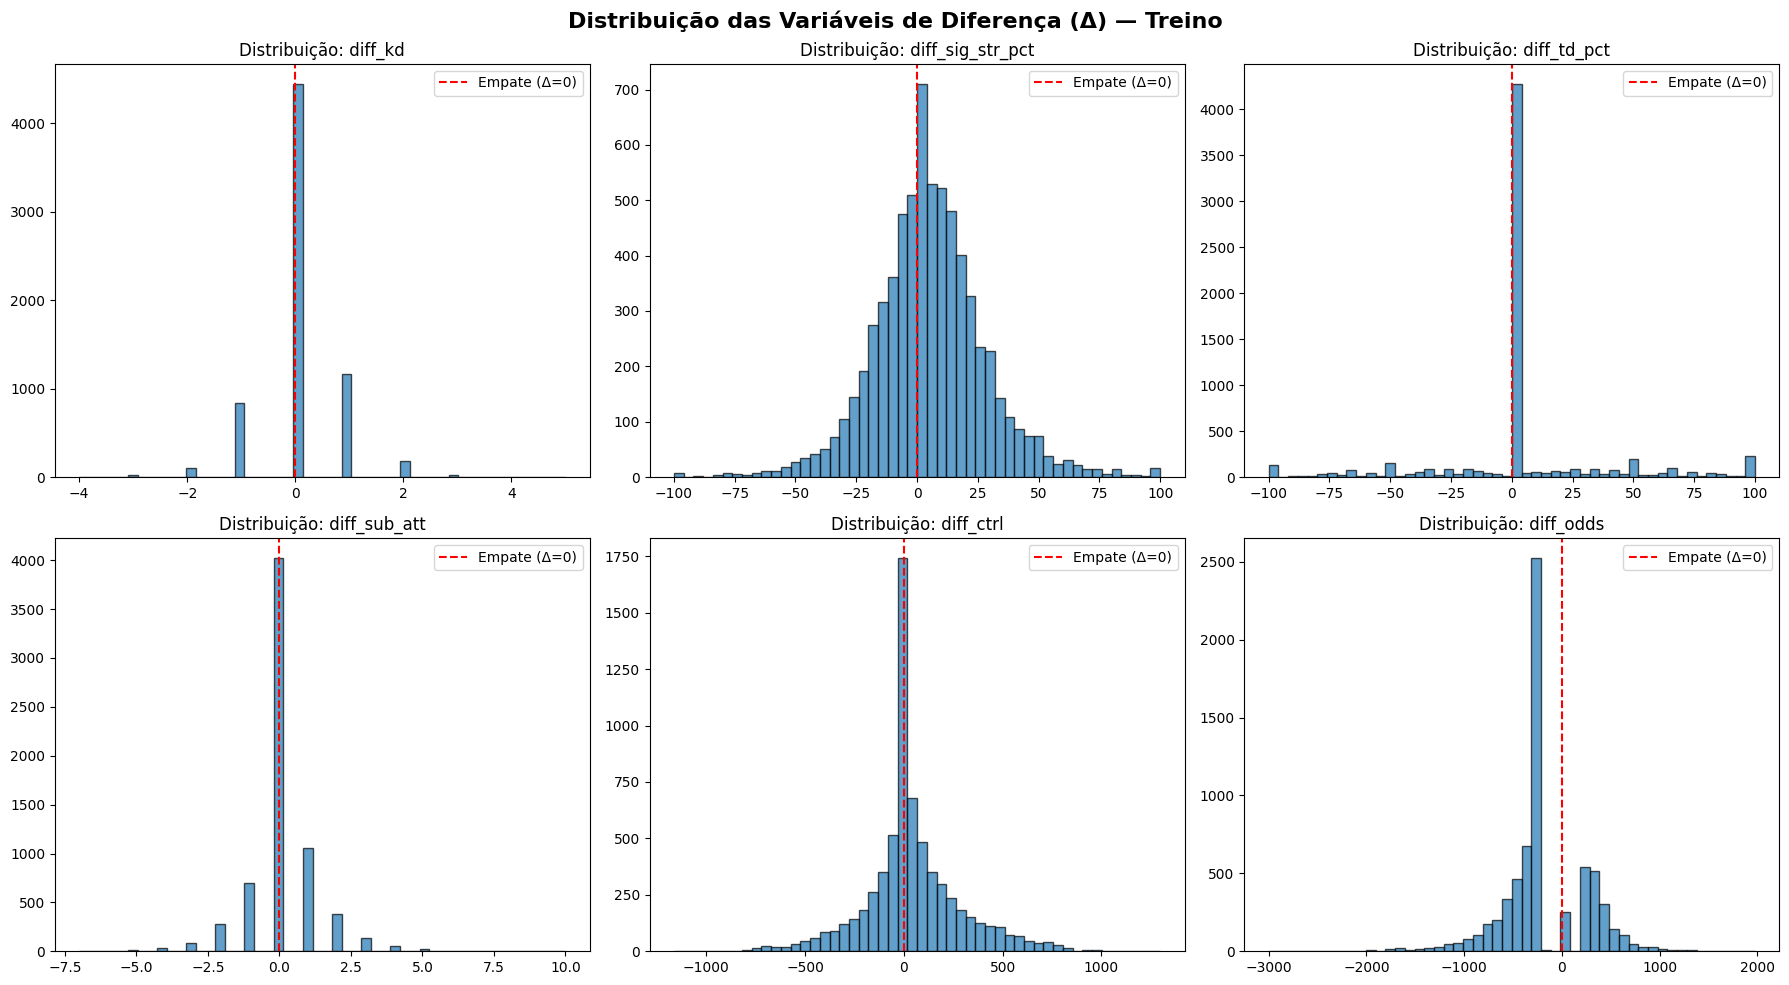

In [40]:
# ============================================================
# VISUALIZAÇÃO RÁPIDA — DISTRIBUIÇÃO DAS NOVAS FEATURES
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

features_delta = ['diff_kd', 'diff_sig_str_pct', 'diff_td_pct', 
                  'diff_sub_att', 'diff_ctrl', 'diff_odds']

for i, feat in enumerate(features_delta):
    row = i // 3
    col = i % 3
    axes[row, col].hist(train[feat].dropna(), bins=50, edgecolor='black', alpha=0.7)
    axes[row, col].set_title(f'Distribuição: {feat}', fontsize=12)
    axes[row, col].axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Empate (Δ=0)')
    axes[row, col].legend()

plt.suptitle('Distribuição das Variáveis de Diferença (Δ) — Treino', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
## 1. diff_kd (diferença de knockdowns)
### Pico gigante no zero — a maioria das lutas não tem knockdown ou ambos lutadores não derrubam ninguém
### Quando sai do zero, é muito assimétrico — um lado derruba e o outro não

## 2. diff_sig_str_pct (diferença de precisão de golpes significativos)
### Distribuição mais normal (formato de sino) centrada próxima de zero
### Isso é bom! Significa que a maioria das lutas tem lutadores com precisão parecida, mas com variação suficiente para o modelo aprender

## 3. diff_td_pct (diferença de eficiência de quedas)
### Pico enorme no zero — muitos lutadores não tentam ou não conseguem quedas
###Quando há diferença, ela pode ser grande (um lutador é wrestler, o outro não)

## 4. diff_sub_att (diferença de tentativas de finalização)
### Mesmo padrão: quase tudo no zero — a maioria não tenta finalizações
### Poucos casos extremos

## 5. diff_ctrl (diferença de tempo de controle)
### Concentrado no zero, com uma cauda longa para os lados
###Quando um lutador controla o outro no chão, a diferença pode ser grande

## 6. diff_odds (diferença de odds)
### O pico NÃO está no zero — está deslocado para a esquerda (valores negativos)
### Isso significa que o mercado de apostas tendia a favorecer o Blue na maioria das lutas


In [50]:
# ============================================================
# ANÁLISE DESCRITIVA DOS DADOS — VERSÃO CORRIGIDA
# ============================================================

# 1. VISÃO GERAL DO DATASET
print("=" * 60)
print("1. VISÃO GERAL DO DATASET")
print("=" * 60)
print(f"Total de lutas: {len(df_master)}")
print(f"Total de colunas: {df_master.shape[1]}")
print(f"Período: {df_master['event_date'].min().date()} a {df_master['event_date'].max().date()}")
print(f"Total de eventos: {df_master['event_name'].nunique()}")
print(f"Total de lutadores (Red): {df_master['red_fighter_name'].nunique()}")
print(f"Total de lutadores (Blue): {df_master['blue_fighter_name'].nunique()}")

# 2. TIPOS DE DADOS (corrigido)
print("\n" + "=" * 60)
print("2. TIPOS DE DADOS")
print("=" * 60)
tipos = df_master.dtypes.astype(str).value_counts()
print(tipos)

# 3. ESTATÍSTICAS DAS VARIÁVEIS DE DIFERENÇA (Δ) — sem diff_total_pts
print("\n" + "=" * 60)
print("3. ESTATÍSTICAS DAS VARIÁVEIS DE DIFERENÇA (Δ)")
print("=" * 60)
colunas_diff = [col for col in df_master.columns 
                if col.startswith('diff_') and col != 'diff_total_pts']
estatisticas = df_master[colunas_diff].describe().T
print(estatisticas[['mean', 'std', 'min', '50%', 'max']].round(2).to_string())

# 4. DISTRIBUIÇÃO DA VARIÁVEL ALVO (red_wins)
print("\n" + "=" * 60)
print("4. DISTRIBUIÇÃO DA VARIÁVEL ALVO (red_wins)")
print("=" * 60)
total = len(df_master)
red_wins = (df_master['red_wins'] == 1).sum()
blue_wins = (df_master['red_wins'] == 0).sum()
print(f"Red wins:    {red_wins} ({red_wins/total*100:.1f}%)")
print(f"Blue wins:   {blue_wins} ({blue_wins/total*100:.1f}%)")
diferenca = abs(red_wins/total - 0.5)
print(f"Balanceamento: {'Balanceado' if diferenca < 0.1 else 'Desbalanceado'}")

# 5. MÉTODOS DE FINALIZAÇÃO
print("\n" + "=" * 60)
print("5. MÉTODOS DE FINALIZAÇÃO")
print("=" * 60)
if 'method' in df_master.columns:
    metodos = df_master['method'].value_counts()
    for metodo, qtd in metodos.items():
        print(f"  {metodo}: {qtd} ({qtd/total*100:.1f}%)")

# 6. VALORES NULOS
print("\n" + "=" * 60)
print("6. VALORES NULOS")
print("=" * 60)
nulos = df_master.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
if len(nulos) > 0:
    print(f"Colunas com nulos: {len(nulos)}")
    print(f"Total de nulos: {nulos.sum()}")
    print(nulos.head(10))
else:
    print("Nenhum valor nulo restante!")

# 7. CORRELAÇÃO COM A VARIÁVEL ALVO (red_wins) — sem diff_total_pts
print("\n" + "=" * 60)
print("7. CORRELAÇÃO COM A VARIÁVEL ALVO (red_wins)")
print("=" * 60)
corr = df_master[colunas_diff + ['red_wins']].corr()['red_wins'].sort_values(ascending=False)
corr = corr.drop('red_wins')
print(corr.round(3).to_string())

# 8. TOP 5 VARIÁVEIS MAIS CORRELACIONADAS
print("\n" + "=" * 60)
print("8. TOP 5 PREDITORES DE VITÓRIA")
print("=" * 60)
top5 = corr.abs().sort_values(ascending=False).head(5)
for var, valor in top5.items():
    sinal = "positiva" if corr[var] > 0 else "negativa"
    print(f"  {var}: r={corr[var]:.3f} (correlação {sinal})")

1. VISÃO GERAL DO DATASET
Total de lutas: 8581
Total de colunas: 152
Período: 1994-03-11 a 2026-06-27
Total de eventos: 779
Total de lutadores (Red): 1973
Total de lutadores (Blue): 2504

2. TIPOS DE DADOS
float64           68
int64             58
str               25
datetime64[us]     1
Name: count, dtype: int64

3. ESTATÍSTICAS DAS VARIÁVEIS DE DIFERENÇA (Δ)
                         mean     std     min    50%     max
diff_kd                  0.06    0.73    -6.0    0.0     5.0
diff_sig_str_pct         4.02   22.71  -100.0    3.0   100.0
diff_td_pct              2.55   34.87  -100.0    0.0   100.0
diff_sub_att             0.12    1.12    -7.0    0.0    10.0
diff_rev                -0.00    0.48    -4.0    0.0     5.0
diff_ctrl               39.29  248.79 -1247.0    5.0  1297.0
diff_sig_str_head        3.14   21.49  -134.0    3.0   175.0
diff_sig_str_body        0.92    9.01   -85.0    0.0   101.0
diff_sig_str_leg         0.39    9.13   -92.0    0.0    61.0
diff_sig_str_distance    1